In [1]:
import os, sys
from pathlib import Path
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

# make tidy/src importable
sys.path.append(os.path.abspath("../src"))

# outputs
OUT_PROB = Path("../outputs/unet_prob")
OUT_BIN  = Path("../outputs/unet_bin")
OUT_VIS  = Path("../outputs/vis")
OUT_PROB.mkdir(parents=True, exist_ok=True)
OUT_BIN.mkdir(parents=True, exist_ok=True)
OUT_VIS.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_H, IMG_W = 360, 640

# IMPORTANT: point to your checkpoint
CKPT_PATH = Path("../../models/checkpoints/unet_tusimple_best.pt")  # adjust if needed


In [2]:
from models import UNetSmall


In [3]:
def load_unet(ckpt_path: Path):
    model = UNetSmall().to(DEVICE)
    ckpt = torch.load(str(ckpt_path), map_location=DEVICE)

    # your checkpoint uses ckpt["model"]
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model

model = load_unet(CKPT_PATH)
print("Loaded model from:", CKPT_PATH)


Loaded model from: ..\..\models\checkpoints\unet_tusimple_best.pt


C:\Users\ankit\AppData\Local\Temp\ipykernel_24616\748020332.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(ckpt_path), map_location=DEVICE)


In [4]:
def preprocess_frame_bgr(frame_bgr):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (IMG_W, IMG_H), interpolation=cv2.INTER_LINEAR)
    x = (rgb.astype(np.float32) / 255.0)
    x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0)
    return x, rgb


In [5]:
def unet_predict_masks(frame_bgr, thr=0.30):
    x, rgb_resized = preprocess_frame_bgr(frame_bgr)
    with torch.no_grad():
        logits = model(x.to(DEVICE))
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()  # HxW, 0..1

    bin_mask = (prob >= thr).astype(np.uint8) * 255
    return rgb_resized, prob, bin_mask


In [8]:
# Put one test image path here
img_path = Path(r"E:\dl_cv_mini_project\road_lane_detection\data\raw\tusimple\test_set\clips\0530\1492626047222176976_0\13.jpg")  # change to a real jpg file path
# Example: img_path = Path(r"../../data/raw/tusimple/test_set/clips/0313-1/6040/20.jpg")

frame = cv2.imread(str(img_path))
assert frame is not None, f"Cannot read image: {img_path}"

thr = 0.30
rgb_resized, prob, bin_mask = unet_predict_masks(frame, thr=thr)

# --------- UNIQUE SAFE NAME (IMPORTANT FIX) ----------
parts = img_path.parts[-3:]   # e.g. ["0530", "1492626047222176976_0", "13.jpg"]
safe_name = "__".join(parts).replace(".jpg", "")

prob_img = (prob * 255).clip(0, 255).astype(np.uint8)

# save probability mask
cv2.imwrite(
    str(OUT_PROB / f"{safe_name}_prob.png"),
    prob_img
)

# save binary mask
cv2.imwrite(
    str(OUT_BIN / f"{safe_name}_bin.png"),
    bin_mask
)

# 🔴 VERY IMPORTANT: save the resized original image too
cv2.imwrite(
    str(OUT_VIS / f"{safe_name}_orig.png"),
    cv2.cvtColor(rgb_resized, cv2.COLOR_RGB2BGR)
)

print("Saved:")
print(OUT_PROB / f"{safe_name}_prob.png")
print(OUT_BIN  / f"{safe_name}_bin.png")
print(OUT_VIS  / f"{safe_name}_orig.png")



Saved:
..\outputs\unet_prob\0530__1492626047222176976_0__13_prob.png
..\outputs\unet_bin\0530__1492626047222176976_0__13_bin.png
..\outputs\vis\0530__1492626047222176976_0__13_orig.png


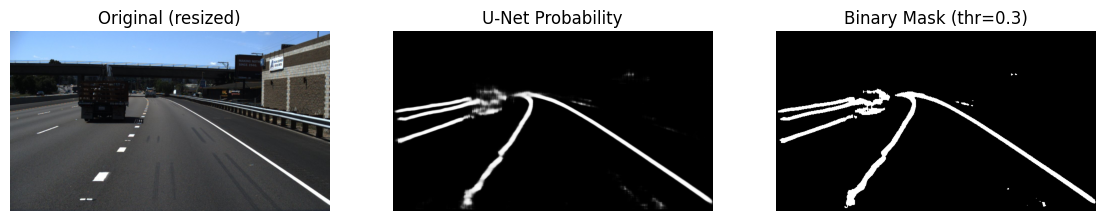

In [9]:
plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.title("Original (resized)"); plt.imshow(rgb_resized); plt.axis("off")
plt.subplot(1,3,2); plt.title("U-Net Probability"); plt.imshow(prob, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title(f"Binary Mask (thr={thr})"); plt.imshow(bin_mask, cmap="gray"); plt.axis("off")
plt.show()
